In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append("..")

In [3]:
from constrerl.eval.evaluate import (
    eval_submission_concept_level_RE,
    eval_submission_mention_level_RE,
    eval_submission_NER,
    eval_submission_NERD,
    remove_duplicated_entities,
    remove_overlapping_entities,
    remove_duplicated_concept_level_relations,
    remove_duplicated_mention_level_relations
)
from constrerl.utils import (
    extract_flags_from_name,
    calculate_relative_improvements,
    task_id_to_name
)
from constrerl.erl_schema import AnnotatedArticle
import glob
from pathlib import Path
import json
import pandas as pd
from collections.abc import Callable

import re


In [4]:
report_dir = Path("report")
# ONTUG results
# report_dir = report_dir / "dev-tugw"
# results_dir = "../data/merge_dev"
# merge_caption = ", including the results of the merged approaches with Graphwise."
# lbl_xtra = ":merge_dev"
# mode = "Merged Development"
# Dev results
report_dir = report_dir / "dev"
results_dir = "../data/results_dev"
merge_caption = "."
lbl_xtra = ":results_dev"
mode = "Development"

ground_truth_file = "../data/Annotations/Dev/json_format/dev.json"
report_dir.mkdir(exist_ok=True, parents=True)
results_dir = Path(results_dir)
ground_truth_file = Path(ground_truth_file)




k_limits = [None]

with open(ground_truth_file) as f:
    ground_truth = json.load(f)
ground_truth_articles: dict[str, AnnotatedArticle] = {}
for k, v in ground_truth.items():
    ground_truth_articles[k] = AnnotatedArticle.model_validate(v)

In [5]:
from inference import AnnotationTypes
from constrerl.utils import extract_flags_from_name


eval_results: list[dict] = []


def scoring_to_dict(
    predictions: dict, eval_f: Callable[[dict, dict], tuple[float]], gt=ground_truth
) -> dict:
    precision, recall, f1, micro_precision, micro_recall, micro_f1 = eval_f(
        predictions, gt
    )
    return {
        "$P$": precision,
        "$R$": recall,
        "$F_1$": f1,
        "$P_{micro}$": micro_precision,
        "$R_{micro}$": micro_recall,
        "$F_{1,micro}$": micro_f1,
    }


def scoring_to_df(
    eval_f: Callable[[str | Path, dict], tuple[float]],
    key: str,
    res_dir=results_dir,
    k_limits_set=None,
    cap_gt=False,
    typ: AnnotationTypes | None = None,
) -> pd.DataFrame:
    eval_results: list[dict] = []
    merge_mode = "merge" in str(res_dir)
    further_mode = False  # not (("old" in str(res_dir)) or ("merge" in str(res_dir)))
    print(f"Further mode: {further_mode}")
    files = list(res_dir.glob("*.json"))
    print(f"Found {len(files)} json files in {res_dir}.")
    if not res_dir.is_dir():
        files = [res_dir]
    for result_file in files:
        result_file = Path(result_file)
        if typ is not None and (typ.value not in result_file.name):
            if "base" not in result_file.name:
                continue

        print(
            "Considering file:",
            result_file,
            "with k limits:",
            k_limits_set,
            "for finetune type:",
            typ,
        )
        try:
            with open(result_file, "r", encoding="utf-8") as file:
                predictions: dict = json.load(file)
        except OSError:
            raise OSError(f"Error in opening the specified json file: {result_file}")

        if k_limits_set is None or len(k_limits_set) == 0:
            k_list = [None]
        else:
            k_list = k_limits_set
        for k in k_list:
            predictions_limited = predictions.copy()
            predictions_limited = {
                id: {
                    key: predictions_limited[id][key][:k]
                    if key in predictions_limited[id]
                    else []
                }
                for id in predictions_limited.keys()
            }
            all_empty = True
            for id in predictions_limited.keys():
                if len(predictions_limited[id][key]) > 0:
                    all_empty = False
                    break
            if all_empty:
                print(f"Skipping {k}/{result_file} due to all empty predictions.")
                continue
            k_gt: dict = ground_truth.copy()
            if cap_gt:
                k_gt = {id: {key: k_gt[id][key][:k]} for id in k_gt.keys()}

            eval_result = None
            try:
                eval_result = scoring_to_dict(predictions_limited, eval_f, gt=k_gt)
            except Exception as e:
                print(f"Error in evaluating {result_file} with k={k}: {e}")
                continue
            all_zero = all(v == 0.0 for v in eval_result.values())
            if all_zero:
                print(f"Skipping {k}/{result_file} due to all zero scores.")
                continue
            result_dict = extract_flags_from_name(
                result_file.name, merge_mode=merge_mode, k=k
            )
            result_dict.update(eval_result)
            # result_dict.update({f"6_2_2_{k}": v for k, v in ternary_tag_score.items()})
            # result_dict.update({f"6_2_3_{k}": v for k, v in ternary_mention_score.items()})
            eval_results.append(result_dict)
    eval_df = pd.DataFrame(eval_results)
    # if further_mode and "$k$" not in eval_df.columns:
    #     eval_df = eval_df[(eval_df["Long $t$"] == "\checkmark")]
    # if merge_mode:
    #     eval_df = eval_df[eval_df["Model"].str.contains("Hermes 3B")]
    valid_cols = [
        c
        for c in [
            "Graphwise",
            "Set",
            "Model",
            "Beams",
            "NED FT",
            "RAG",
            "LoRA",
            "Naive",
            "Filter",
        ]
        if c in eval_df.columns
    ]
    print(
        f"Valid columns for indexing: {valid_cols} (from {eval_df.columns.tolist()}), found result: {len(eval_df)}"
    )
    eval_df.set_index(valid_cols, inplace=True)
    eval_df = eval_df.sort_index()
    # if "$F_{1,micro}$" in eval_df.columns:
    #     eval_df = eval_df.sort_values("$F_{1,micro}$")
    return eval_df


task_6_1_1_df = scoring_to_df(
    eval_submission_NER, "entities", typ=AnnotationTypes.ENTITY
)
task_6_1_2_df = scoring_to_df(
    eval_submission_NERD, "entities", typ=AnnotationTypes.ENTITY
)
task_6_2_1_df = scoring_to_df(
    eval_submission_mention_level_RE,
    "mention_level_relations",
    typ=AnnotationTypes.RELATION,
)
task_6_2_2_df = scoring_to_df(
    eval_submission_concept_level_RE,
    "concept_level_relations",
    typ=AnnotationTypes.RELATION,
)

Further mode: False
Found 83 json files in ../data/results_dev.
Considering file: ../data/results_dev/eval_naive-entities.json with k limits: None for finetune type: AnnotationTypes.ENTITY
=== Removed 6476 duplicated entities from predictions ===
=== Removed 4145 overlapping entities ===
Considering file: ../data/results_dev/eval_hermes_neefinetuned-rag-lora-entities-naive-beam-none-hermes-3-2-3B-entities.json with k limits: None for finetune type: AnnotationTypes.ENTITY
=== Removed 6598 duplicated entities from predictions ===
=== Removed 5610 overlapping entities ===
Considering file: ../data/results_dev/eval_hermes-rag-beam-none-hermes-3-2-3B-base.json with k limits: None for finetune type: AnnotationTypes.ENTITY
=== Removed 35 duplicated entities from predictions ===
Considering file: ../data/results_dev/eval_hermes-rag-beam-none-hermes-3-1-8B-base.json with k limits: None for finetune type: AnnotationTypes.ENTITY
=== Removed 15 duplicated entities from predictions ===
=== Removed 

In [6]:
task_6_1_1_df = scoring_to_df(eval_submission_NER, "entities", typ=AnnotationTypes.ENTITY)
task_6_1_1_df

Further mode: False
Found 83 json files in ../data/results_dev.
Considering file: ../data/results_dev/eval_naive-entities.json with k limits: None for finetune type: AnnotationTypes.ENTITY
=== Removed 6476 duplicated entities from predictions ===
=== Removed 4145 overlapping entities ===
Considering file: ../data/results_dev/eval_hermes_neefinetuned-rag-lora-entities-naive-beam-none-hermes-3-2-3B-entities.json with k limits: None for finetune type: AnnotationTypes.ENTITY
=== Removed 6598 duplicated entities from predictions ===
=== Removed 5610 overlapping entities ===
Considering file: ../data/results_dev/eval_hermes-rag-beam-none-hermes-3-2-3B-base.json with k limits: None for finetune type: AnnotationTypes.ENTITY
=== Removed 35 duplicated entities from predictions ===
Considering file: ../data/results_dev/eval_hermes-rag-beam-none-hermes-3-1-8B-base.json with k limits: None for finetune type: AnnotationTypes.ENTITY
=== Removed 15 duplicated entities from predictions ===
=== Removed 

$P$  \
Model  Beams    NED FT     RAG        LoRA       Naive      Filter                 
3.1 8B $\times$ $\times$   $\times$   $\times$   $\times$   $\times$    0.103826   
                                                 \checkmark $\times$    0.428541   
                                      \checkmark $\times$   $\times$    0.316348   
                                                 \checkmark $\times$    0.436229   
                           \checkmark $\times$   $\times$   $\times$    0.439343   
                                                 \checkmark $\times$    0.461237   
                                      \checkmark $\times$   $\times$    0.360958   
                                                 \checkmark $\times$    0.468399   
                \checkmark $\times$   $\times$   \checkmark $\times$    0.485546   
                                      \checkmark \checkmark $\times$    0.483859   
                           \checkmark $\times$   $\times$   $\times$    0.000052   
                                                 \checkmark $\times$    0.476240   
                                      \checkmark $\times$   $\times$    0.000084   
                                                 \checkmark $\times$    0.495963   
       End      \checkmark $\times$   $\times$   \checkmark $\times$    0.507570   
                                      \checkmark $\times$   $\times$    0.003077   
                                                 \checkmark $\times$    0.498451   
                           \checkmark $\times$   $\times$   $\times$    0.001221   
                                      \checkmark \checkmark $\times$    0.505371   
3.2 3B $\times$ $\times$   $\times$   $\times$   $\times$   $\times$    0.126060   
                                                 \checkmark $\times$    0.448207   
                                      \checkmark $\times$   $\times$    0.136490   
                                                 \checkmark $\times$    0.473553   
                           \checkmark $\times$   $\times$   $\times$    0.311033   
                                                 \checkmark $\times$    0.452317   
                                      \checkmark $\times$   $\times$    0.348357   
                                                 \checkmark $\times$    0.479939   
                \checkmark $\times$   $\times$   \checkmark $\times$    0.490206   
                                      \checkmark $\times$   $\times$    0.000081   
                                                 \checkmark $\times$    0.496756   
                           \checkmark $\times$   $\times$   $\times$    0.000106   
                                                 \checkmark $\times$    0.484257   
                                      \checkmark $\times$   $\times$    0.000085   
                                                 \checkmark $\times$    0.486980   
       End      \checkmark $\times$   \checkmark \checkmark $\times$    0.503816   
                           \checkmark $\times$   $\times$   $\times$    0.001399   
                                                 \checkmark $\times$    0.519663   
                                      \checkmark \checkmark $\times$    0.495035   
Naive  $\times$ $\times$   $\times$   $\times$   \checkmark $\times$    0.494321   
                                                            \checkmark  0.500100   

                                                                             $R$  \
Model  Beams    NED FT     RAG        LoRA       Naive      Filter                 
3.1 8B $\times$ $\times$   $\times$   $\times$   $\times$   $\times$    0.032553   
                                                 \checkmark $\times$    0.693398   
                                      \checkmark $\times$   $\times$    0.127245   
                                                 \checkmark $\times$    0.640298   
                           \checkmark $\time

In [7]:
task_6_1_1_df.shape

(40, 6)

In [8]:
from typing import Any
from constrerl.utils import calculate_improvements, df_topk


task_6_1_1_df_improved = calculate_improvements(task_6_1_1_df)
median_improvements = task_6_1_1_df_improved.mean()
task_6_1_1_df_improved

Calculating improvements based on keys: ['Beams'] with options: [('Beams', ['End'])] / other keys: ['Model', 'NED FT', 'RAG', 'LoRA', 'Naive', 'Filter']
Resetting index_cols=['Model', 'Beams', 'NED FT', 'RAG', 'LoRA', 'Naive', 'Filter']


$P$  \
Model  Beams NED FT     RAG        LoRA       Naive      Filter               
3.1 8B End   \checkmark $\times$   $\times$   \checkmark $\times$  0.022024   
                                   \checkmark \checkmark $\times$  0.014592   
                        \checkmark $\times$   $\times$   $\times$  0.001169   
                                   \checkmark \checkmark $\times$  0.009408   
3.2 3B End   \checkmark $\times$   \checkmark \checkmark $\times$  0.007059   
                        \checkmark $\times$   $\times$   $\times$  0.001293   
                                              \checkmark $\times$  0.035407   
                                   \checkmark \checkmark $\times$  0.008055   

                                                                        $R$  \
Model  Beams NED FT     RAG        LoRA       Naive      Filter               
3.1 8B End   \checkmark $\times$   $\times$   \checkmark $\times$ -0.005342   
                                   \checkmark \checkmark $\times$ -0.426370   
                        \checkmark $\times$   $\times$   $\times$  0.000323   
                                   \checkmark \checkmark $\times$ -0.089317   
3.2 3B End   \checkmark $\times$   \checkmark \checkmark $\times$ -0.036403   
                        \checkmark $\times$   $\times$   $\times$  0.000226   
                                              \checkmark $\times$ -0.123473   
                                   \checkmark \checkmark $\times$ -0.033018   

                                                                      $F_1$  \
Model  Beams NED FT     RAG        LoRA       Naive      Filter               
3.1 8B End   \checkmark $\times$   $\times$   \checkmark $\times$  0.017047   
                                   \checkmark \checkmark $\times$ -0.192276   
                        \checkmark $\times$   $\times$   $\times$  0.000557   
                                   \checkmark \checkmark $\times$ -0.021335   
3.2 3B End   \checkmark $\times$   \checkmark \checkmark $\times$ -0.005463   
                        \checkmark $\times$   $\times$   $\times$  0.000510   
                                              \checkmark $\times$ -0.021222   
                                   \checkmark \checkmark $\times$ -0.002555   

                                                                   $P_{micro}$  \
Model  Beams NED FT     RAG        LoRA       Naive      Filter                  
3.1 8B End   \checkmark $\times$   $\times$   \checkmark $\times$     0.030852   
                                   \checkmark \checkmark $\times$     0.035382   
                        \checkmark $\times$   $\times$   $\times$     0.000302   
                                   \checkmark \checkmark $\times$     0.029944   
3.2 3B End   \checkmark $\times$   \checkmark \checkmark $\times$     0.030385   
                        \checkmark $\times$   $\times$   $\times$    -0.000226   
                                              \checkmark $\times$     0.039125   
                                   \checkmark \checkmark $\times$     0.028474   

                                                                   $R_{micro}$  \
Model  Beams NED FT     RAG        LoRA       Naive      Filter                  
3.1 8B End   \checkmark $\times$   $\times$   \checkmark $\times$    -0.004363   
                                   \checkmark \checkmark $\times$    -0.448235   
                        \checkmark $\times$   $\times$   $\times$     0.000000   
                                   \checkmark \checkmark $\times$    -0.100357   
3.2 3B End   \checkmark $\times$   \checkmark \checkmark $\times$    -0.024593   
                        \checkmark $\times$   $\times$   $\times$    -0.000397   
                                              \checkmark $\times$    -0.153907   
                                   \checkmark \checkmark $\times$    -0.028957   

                                                         

In [9]:
task_6_1_1_df

$P$  \
Model  Beams    NED FT     RAG        LoRA       Naive      Filter                 
3.1 8B $\times$ $\times$   $\times$   $\times$   $\times$   $\times$    0.103826   
                                                 \checkmark $\times$    0.428541   
                                      \checkmark $\times$   $\times$    0.316348   
                                                 \checkmark $\times$    0.436229   
                           \checkmark $\times$   $\times$   $\times$    0.439343   
                                                 \checkmark $\times$    0.461237   
                                      \checkmark $\times$   $\times$    0.360958   
                                                 \checkmark $\times$    0.468399   
                \checkmark $\times$   $\times$   \checkmark $\times$    0.485546   
                                      \checkmark \checkmark $\times$    0.483859   
                           \checkmark $\times$   $\times$   $\times$    0.000052   
                                                 \checkmark $\times$    0.476240   
                                      \checkmark $\times$   $\times$    0.000084   
                                                 \checkmark $\times$    0.495963   
       End      \checkmark $\times$   $\times$   \checkmark $\times$    0.507570   
                                      \checkmark $\times$   $\times$    0.003077   
                                                 \checkmark $\times$    0.498451   
                           \checkmark $\times$   $\times$   $\times$    0.001221   
                                      \checkmark \checkmark $\times$    0.505371   
3.2 3B $\times$ $\times$   $\times$   $\times$   $\times$   $\times$    0.126060   
                                                 \checkmark $\times$    0.448207   
                                      \checkmark $\times$   $\times$    0.136490   
                                                 \checkmark $\times$    0.473553   
                           \checkmark $\times$   $\times$   $\times$    0.311033   
                                                 \checkmark $\times$    0.452317   
                                      \checkmark $\times$   $\times$    0.348357   
                                                 \checkmark $\times$    0.479939   
                \checkmark $\times$   $\times$   \checkmark $\times$    0.490206   
                                      \checkmark $\times$   $\times$    0.000081   
                                                 \checkmark $\times$    0.496756   
                           \checkmark $\times$   $\times$   $\times$    0.000106   
                                                 \checkmark $\times$    0.484257   
                                      \checkmark $\times$   $\times$    0.000085   
                                                 \checkmark $\times$    0.486980   
       End      \checkmark $\times$   \checkmark \checkmark $\times$    0.503816   
                           \checkmark $\times$   $\times$   $\times$    0.001399   
                                                 \checkmark $\times$    0.519663   
                                      \checkmark \checkmark $\times$    0.495035   
Naive  $\times$ $\times$   $\times$   $\times$   \checkmark $\times$    0.494321   
                                                            \checkmark  0.500100   

                                                                             $R$  \
Model  Beams    NED FT     RAG        LoRA       Naive      Filter                 
3.1 8B $\times$ $\times$   $\times$   $\times$   $\times$   $\times$    0.032553   
                                                 \checkmark $\times$    0.693398   
                                      \checkmark $\times$   $\times$    0.127245   
                                                 \checkmark $\times$    0.640298   
                           \checkmark $\time

In [10]:
task_6_1_1_df

$P$  \
Model  Beams    NED FT     RAG        LoRA       Naive      Filter                 
3.1 8B $\times$ $\times$   $\times$   $\times$   $\times$   $\times$    0.103826   
                                                 \checkmark $\times$    0.428541   
                                      \checkmark $\times$   $\times$    0.316348   
                                                 \checkmark $\times$    0.436229   
                           \checkmark $\times$   $\times$   $\times$    0.439343   
                                                 \checkmark $\times$    0.461237   
                                      \checkmark $\times$   $\times$    0.360958   
                                                 \checkmark $\times$    0.468399   
                \checkmark $\times$   $\times$   \checkmark $\times$    0.485546   
                                      \checkmark \checkmark $\times$    0.483859   
                           \checkmark $\times$   $\times$   $\times$    0.000052   
                                                 \checkmark $\times$    0.476240   
                                      \checkmark $\times$   $\times$    0.000084   
                                                 \checkmark $\times$    0.495963   
       End      \checkmark $\times$   $\times$   \checkmark $\times$    0.507570   
                                      \checkmark $\times$   $\times$    0.003077   
                                                 \checkmark $\times$    0.498451   
                           \checkmark $\times$   $\times$   $\times$    0.001221   
                                      \checkmark \checkmark $\times$    0.505371   
3.2 3B $\times$ $\times$   $\times$   $\times$   $\times$   $\times$    0.126060   
                                                 \checkmark $\times$    0.448207   
                                      \checkmark $\times$   $\times$    0.136490   
                                                 \checkmark $\times$    0.473553   
                           \checkmark $\times$   $\times$   $\times$    0.311033   
                                                 \checkmark $\times$    0.452317   
                                      \checkmark $\times$   $\times$    0.348357   
                                                 \checkmark $\times$    0.479939   
                \checkmark $\times$   $\times$   \checkmark $\times$    0.490206   
                                      \checkmark $\times$   $\times$    0.000081   
                                                 \checkmark $\times$    0.496756   
                           \checkmark $\times$   $\times$   $\times$    0.000106   
                                                 \checkmark $\times$    0.484257   
                                      \checkmark $\times$   $\times$    0.000085   
                                                 \checkmark $\times$    0.486980   
       End      \checkmark $\times$   \checkmark \checkmark $\times$    0.503816   
                           \checkmark $\times$   $\times$   $\times$    0.001399   
                                                 \checkmark $\times$    0.519663   
                                      \checkmark \checkmark $\times$    0.495035   
Naive  $\times$ $\times$   $\times$   $\times$   \checkmark $\times$    0.494321   
                                                            \checkmark  0.500100   

                                                                             $R$  \
Model  Beams    NED FT     RAG        LoRA       Naive      Filter                 
3.1 8B $\times$ $\times$   $\times$   $\times$   $\times$   $\times$    0.032553   
                                                 \checkmark $\times$    0.693398   
                                      \checkmark $\times$   $\times$    0.127245   
                                                 \checkmark $\times$    0.640298   
                           \checkmark $\time

In [11]:
tasks = {
    "6.1.1": task_6_1_1_df,
    "6.1.2": task_6_1_2_df,
    "6.2.1": task_6_2_1_df,
    "6.2.2": task_6_2_2_df,
}
average_improvements = []


for task_name, task_df in tasks.items():
    print(f"Processing Subtask {task_name} with {len(task_df)} results.")
    task_name_formatted = re.sub(r"\.", "_", task_name)

    task_df.style.highlight_max(axis=0, props="textbf:--rwrap;").format(
        lambda v: f"{v:.2f}" if isinstance(v, float) else v
    ).to_latex(
        report_dir / f"task_{task_name_formatted}_full.tex",
        caption=f"{mode} Set Results for Subtask {task_name}" + merge_caption,
        label=f"tab:task:{task_name_formatted}{lbl_xtra}:full",
        clines="all;data",
        hrules=True,
    )
    top_k = 10
    task_df_top = df_topk(task_df, top_k)
    task_df_top.style.highlight_max(axis=0, props="textbf:--rwrap;").format(
        lambda v: f"{v:.2f}" if isinstance(v, float) else v
    ).to_latex(
        report_dir / f"task_{task_name_formatted}_top.tex",
        caption=f"Top {top_k} {mode} Set Results for {task_id_to_name(task_name)} (Subtask {task_name})" + merge_caption,
        label=f"tab:task:{task_name_formatted}{lbl_xtra}",
        clines="all;data",
        hrules=True,
    )
    task_df_improved = calculate_improvements(task_df)
    mean_improvements = task_df_improved.mean()

    task_df_improved.style.format(
        lambda v: (
            f"+\\textcolor{{DarkGreen}}{{{v:.2f}}}"
            if v > 0
            else f"\\textcolor{{DarkRed}}{{{v:.2f}}}"
            if isinstance(v, float)
            else v
        )
    ).to_latex(
        report_dir / f"task_{task_name_formatted}_improve.tex",
        caption=f"{mode} Set Improvements for {task_id_to_name(task_name)} (Subtask {task_name}) when applying beam search" + merge_caption,
        label=f"tab:task:{task_name_formatted}{lbl_xtra}_improve",
        clines="all;data",
        hrules=True,
    )
    average_improvements.append(mean_improvements.to_dict() | {"Subtask": task_name})

Processing Subtask 6.1.1 with 40 results.
Calculating improvements based on keys: ['Beams'] with options: [('Beams', ['End'])] / other keys: ['Model', 'NED FT', 'RAG', 'LoRA', 'Naive', 'Filter']
Resetting index_cols=['Model', 'Beams', 'NED FT', 'RAG', 'LoRA', 'Naive', 'Filter']
Processing Subtask 6.1.2 with 40 results.
Calculating improvements based on keys: ['Beams'] with options: [('Beams', ['End'])] / other keys: ['Model', 'NED FT', 'RAG', 'LoRA', 'Naive', 'Filter']
Resetting index_cols=['Model', 'Beams', 'NED FT', 'RAG', 'LoRA', 'Naive', 'Filter']
Processing Subtask 6.2.1 with 16 results.
Calculating improvements based on keys: ['Beams'] with options: [('Beams', [])] / other keys: ['Model', 'NED FT', 'RAG', 'LoRA', 'Naive', 'Filter']
No improvements calculated. Returning empty DataFrame.
Processing Subtask 6.2.2 with 33 results.
Calculating improvements based on keys: ['Beams'] with options: [('Beams', ['End'])] / other keys: ['Model', 'NED FT', 'RAG', 'LoRA', 'Naive', 'Filter']
Re

In [12]:
avg_improvements_df = pd.DataFrame(average_improvements).set_index("Subtask")
avg_improvements_df.style.format(
    lambda v: f"+{v:.2f}" if v > 0 else f"{v:.2f}" if isinstance(v, float) else v, na_rep="-"
).to_latex(
    report_dir / "average_improvements.tex",
    caption="Average improvements across all subtasks by applying Beam Search"
    + merge_caption,
    label=f"tab:average_improvements{lbl_xtra}",
    clines="all;data",
    hrules=True,
)

In [13]:
from constrerl.utils import calculate_relative_improvements

pairs = {
    "Subtask 6.1": [task_6_1_1_df, task_6_1_2_df],
    "Subtask 6.2": [task_6_2_1_df, task_6_2_2_df],
}
for task_name, (df1, df2) in pairs.items():
    task_name_formatted = re.sub(r"(\.| )", "_", task_name).strip().lower()
    disambiguation_changes = calculate_relative_improvements(df1, df2)
    disambiguation_changes.style.format(
        lambda v: (
            f"+\\textcolor{{DarkGreen}}{{{v:.2f}}}"
            if v > 0
            else f"\\textcolor{{DarkRed}}{{{v:.2f}}}"
            if isinstance(v, float)
            else v
        )
    ).to_latex(
        report_dir / f"{task_name_formatted}_disambiguation.tex",
        caption=f"{mode} Set Disambiguation Changes for {task_id_to_name(task_name.split(' ')[-1])} between {task_id_to_name(f'{task_name.split(' ')[-1]}.1')} and {task_id_to_name(f'{task_name.split(' ')[-1]}.2')}.",
        label=f"tab:task:{task_name_formatted}{lbl_xtra}_disambiguation",
        clines="all;data",
        hrules=True,
    )
disambiguation_changes

$F_1$  \
Model  Beams    NED FT   RAG        LoRA       Naive      Filter               
3.1 8B $\times$ $\times$ $\times$   \checkmark $\times$   $\times$  0.003374   
                                               \checkmark $\times$  0.004382   
                         \checkmark $\times$   $\times$   $\times$  0.020289   
                                               \checkmark $\times$  0.020289   
3.2 3B $\times$ $\times$ $\times$   \checkmark $\times$   $\times$  0.008106   
                                               \checkmark $\times$  0.007738   
                         \checkmark $\times$   $\times$   $\times$  0.008895   
                                               \checkmark $\times$  0.008895   
                                    \checkmark $\times$   $\times$ -0.000271   
                                               \checkmark $\times$ -0.000271   

                                                                    $F_{1,micro}$  \
Model  Beams    NED FT   RAG        LoRA       Naive      Filter                    
3.1 8B $\times$ $\times$ $\times$   \checkmark $\times$   $\times$      -0.011122   
                                               \checkmark $\times$      -0.011980   
                         \checkmark $\times$   $\times$   $\times$       0.002154   
                                               \checkmark $\times$       0.002154   
3.2 3B $\times$ $\times$ $\times$   \checkmark $\times$   $\times$      -0.011357   
                                               \checkmark $\times$      -0.011352   
                         \checkmark $\times$   $\times$   $\times$       0.007653   
                                               \checkmark $\times$       0.007653   
                                    \checkmark $\times$   $\times$      -0.017324   
                                               \checkmark $\times$      -0.017324   

                                                                    Relative $F_1$  \
Model  Beams    NED FT   RAG        LoRA       Naive      Filter                     
3.1 8B $\times$ $\times$ $\times$   \checkmark $\times$   $\times$        0.074989   
                                               \checkmark $\times$        0.101118   
                         \checkmark $\times$   $\times$   $\times$        0.395779   
                                               \checkmark $\times$        0.395779   
3.2 3B $\times$ $\times$ $\times$   \checkmark $\times$   $\times$        0.259740   
                                               \checkmark $\times$        0.263804   
                         \checkmark $\times$   $\times$   $\times$        0.243475   
                                               \checkmark $\times$        0.243475   
                                    \checkmark $\times$   $\times$       -0.010366   
                                               \checkmark $\times$       -0.010366   

                                                                    Relative $F_{1,micro}$  
Model  Beams    NED FT   RAG        LoRA       Naive      Filter                            
3.1 8B $\times$ $\times$ $\times$   \checkmark $\times$   $\times$               -0.114901  
                                               \checkmark $\times$               -0.127680  
                         \checkmark $\times$   $\times$   $\times$                0.030636  
                                               \checkmark $\times$                0.030636  
3.2 3B $\times$ $\times$ $\times$   \checkmark $\times$   $\times$               -0.120989  
                                               \checkmark $\times$               -0.125202  
                         \checkmark $\times$   $\times$   $\times$                0.138100  
                                               \checkmark $\times$                0.138100  
                                    \checkmark $\times$   $\times$               -0.220303  
                                 

In [14]:
task_name_formatted

'subtask_6_2'

In [15]:
for art in ground_truth_articles.values():
    print(art.metadata.title, len(art.entities), len(art.relations))

Orthopedic Surgery Causes Gut Microbiome Dysbiosis and Intestinal Barrier Dysfunction in Prodromal Alzheimer Disease Patients: A Prospective Observational Cohort Study. 45 45
Cadmium exposure modulates the gut-liver axis in an Alzheimer's disease mouse model. 24 15
Exploring the mycobiota in multiple sclerosis: its influence on disease development and progression. 33 66
Potential benefits of kefir and its compounds on Alzheimer's disease: A systematic review. 34 6
In-depth investigation of the mechanisms of Schisandra chinensis polysaccharide mitigating Alzheimer's disease rat via gut microbiota and feces metabolomics. 37 14
Mining the microbiota to identify gut commensals modulating neuroinflammation in a mouse model of multiple sclerosis. 30 7
Polysaccharides extracted from common buckwheat (Fagopyrum esculentum) attenuate cognitive impairment via suppressing RAGE/p38/NF-κB signaling and dysbiosis in AlCl<sub>3</sub>-treated rats. 60 9
Gut microbiota and autoimmune neurologic disorde

In [16]:
import numpy as np
np.array([len(d.model_dump()["entities"]) for d in ground_truth_articles.values()]).mean()

np.float64(31.5125)

=== Removed 6355 duplicated entities from predictions ===
=== Removed 4415 overlapping entities ===
Using max_k=288 based on predictions with average number of annotations: 46.95 (sets: 3.00) and average number of GT annotations: 31.51, max_k=288
Further mode: False
Found 0 json files in ../data/results_dev/eval_hermes_neefinetuned-naive-beam-end-hermes-3-1-8B-base.json.
Considering file: ../data/results_dev/eval_hermes_neefinetuned-naive-beam-end-hermes-3-1-8B-base.json with k limits: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 1

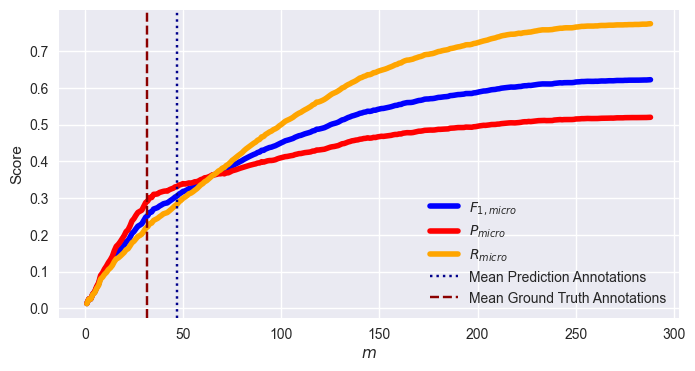

In [17]:
import colorsys

from constrerl.utils import EvalData

import matplotlib.pyplot as plt
import tikzplotlib
import re

# style to sbn
plt.style.use("seaborn-v0_8")


def tikzplotlib_fix_ncols(obj):
    """
    workaround for matplotlib 3.6 renamed legend's _ncol to _ncols, which breaks tikzplotlib
    """
    if hasattr(obj, "_ncols"):
        obj._ncol = obj._ncols
    for child in obj.get_children():
        tikzplotlib_fix_ncols(child)


def vary_over_k(
    fn="eval_hermes_neefinetuned-naive-beam-end-hermes-3-1-8B-base.json",
    max_k: int | None = None,
    out_file="f1_at_k_ner.tex",
    score_method=eval_submission_NER,
    score_name="entities",
    title=f" Varying $k$ for {task_id_to_name('6.1.1')} (Subtask 6.1.1) with \n NED finetune + Beam Search to End + Naive using Hermes 3B",
):

    annotated_articles: dict[str, EvalData] = {}
    with open(results_dir / fn, "r", encoding="utf-8") as file:
        preds: dict = json.load(file)
        if score_name == "entities":
            remove_duplicated_entities(preds)
            remove_overlapping_entities(preds)
        elif score_name == "mention_level_relations":
            remove_duplicated_mention_level_relations(preds)
        else:
            remove_duplicated_concept_level_relations(preds)

        for k, v in preds.items():
            annotated_articles[k] = EvalData.model_validate(v)
        annoted_ie_sets: dict[str, list] = preds
    avg_num_annotations_sets = np.array([len(d) for d in annoted_ie_sets.values()]).mean()
    avg_num_annotations = np.array([len(d.model_dump()[score_name]) for d in annotated_articles.values()]).mean()
    avg_num_gt_annotations = np.array([len(d.model_dump()[score_name]) for d in ground_truth_articles.values()]).mean()
    if max_k is None:
        ks = []
        for id in annotated_articles.keys():
            d = annotated_articles[id]
            d_data = d.model_dump()
            k = len(d_data[score_name])
            ks.append(k)
        max_k = max(ks)*3
    print(f"Using max_k={max_k} based on predictions with average number of annotations: {avg_num_annotations:.2f} (sets: {avg_num_annotations_sets:.2f}) and average number of GT annotations: {avg_num_gt_annotations:.2f}, {max_k=}")
    k = list(range(1, max_k + 1))

    f_at_k = scoring_to_df(
        score_method,
        score_name,
        k_limits_set=k,
        cap_gt=True,
        res_dir=results_dir / fn,
    )
    k_s = f_at_k.reset_index()["$k$"].to_numpy()
    seriess = ["$F_{1,micro}$", "$P_{micro}$", "$R_{micro}$"]
    colors = ["blue", "red", "orange"]
    stack = np.stack([f_at_k[s].to_numpy() for s in seriess], axis=1)
    max_score = stack.max()

    fig = plt.figure(figsize=(8, 4))
    ax = fig.add_subplot(111)
    for i, s in enumerate(seriess):
        ax.plot(k_s, f_at_k[s].to_numpy(), label=s, color=colors[i], linewidth=4)
    ax.axvline(avg_num_annotations, color="darkblue", linestyle=":", label="Mean Prediction Annotations")
    ax.axvline(avg_num_gt_annotations, color="darkred", linestyle="--", label="Mean Ground Truth Annotations")
    ax.set_ylabel("Score")
    ax.set_xlabel("$m$")
    # ax.set_title(title)
    ax.legend()
    # ax.set_xticklabels(k_s)
    y_tick_div = 0.1 if max_score > 0.5 else 0.05

    ax.set_yticks(np.arange(0, max_score, y_tick_div))
    tikzplotlib_fix_ncols(fig)
    tikzplotlib.save(
        report_dir / out_file,
        figure=fig,
        axis_width="0.8\\linewidth",
        axis_height="0.4\\linewidth",
        # extra_axis_parameters={
        #     "legend style": r"legend pos=outer north east",
        #     "legend columns": 1,
        #     "legend cell align": "left",
        #     "legend to name": "loss_legend",
        #     "legend entries": ["loss"],
        # },
    )


vary_over_k()

=== Removed 6355 duplicated entities from predictions ===
=== Removed 4415 overlapping entities ===
Using max_k=288 based on predictions with average number of annotations: 46.95 (sets: 3.00) and average number of GT annotations: 31.51, max_k=288
Further mode: False
Found 0 json files in ../data/results_dev/eval_hermes_neefinetuned-naive-beam-end-hermes-3-1-8B-base.json.
Considering file: ../data/results_dev/eval_hermes_neefinetuned-naive-beam-end-hermes-3-1-8B-base.json with k limits: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 1

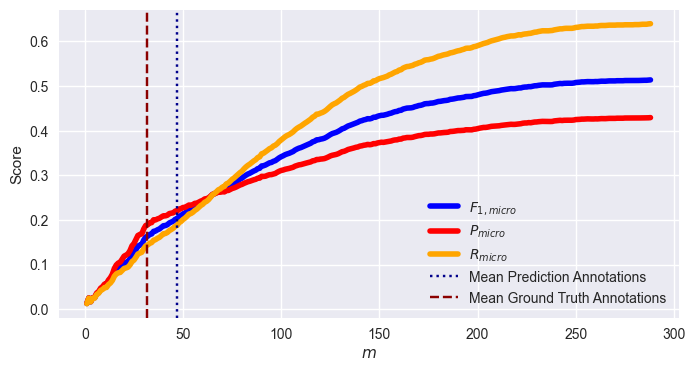

In [18]:
vary_over_k(
    fn="eval_hermes_neefinetuned-naive-beam-end-hermes-3-1-8B-base.json",
    max_k=None,
    out_file="f1_at_k_nerd.tex",
    score_method=eval_submission_NERD,
    score_name="entities",
    title=f"Scores @  $k$ for {task_id_to_name('6.1.2')} (Subtask 6.1.2) with NED finetune + Beam Serach to End + Naive Enrichment using Hermes 3B",
)

In [19]:
# vary_over_k(
#     fn="eval_hermes_neefinetuned-rag-lora-relations-naive-beam-none-hermes-3-1-8B-relations.json",
#     max_k=None,
#     out_file="f1_at_k_re.tex",
#     score_method=eval_submission_mention_level_RE,
#     score_name="mention_level_relations",
#     title="Scores @  $k$ for Subtask 6.2.1 with Hermes 8B Lora",
# )

=== Removed 301 duplicated concept-level relations from predictions ===
Using max_k=78 based on predictions with average number of annotations: 12.31 (sets: 3.00) and average number of GT annotations: 11.11, max_k=78
Further mode: False
Found 0 json files in ../data/results_dev/eval_hermes_neefinetuned-rag-lora-relations-naive-beam-none-hermes-3-1-8B-relations.json.
Considering file: ../data/results_dev/eval_hermes_neefinetuned-rag-lora-relations-naive-beam-none-hermes-3-1-8B-relations.json with k limits: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78] for finetune type: None
Skipping 1/../data/results_dev/eval_hermes_neefinetuned-rag-lora-relations-naive-beam-none-hermes-3-1-8B-relations.json due to all zero scores.
=== Removed 3 dup

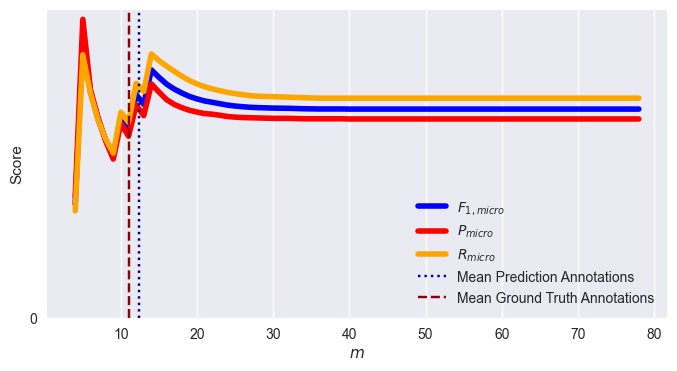

In [20]:
vary_over_k(
    fn="eval_hermes_neefinetuned-rag-lora-relations-naive-beam-none-hermes-3-1-8B-relations.json",
    max_k=None,
    out_file="f1_at_k_red.tex",
    score_method=eval_submission_concept_level_RE,
    score_name="concept_level_relations",
    title=f"Scores @  $k$ for {task_id_to_name('6.2.2')} (Subtask 6.2.2) with Hermes 8B Lora",
)